# Oppgave 3
Definerer simulasjon for alternerende potensialer

In [23]:
#Importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt
import scipy
import random

#Setter opp plotteparametere
plt.rcParams['figure.figsize'] = [12, 8]  # Width, Height in inches


# Sannsynlighetstettheter for steg til høyre, venstre og ingen steg.
def p_plus(x, V):
    return 1/(1+np.exp(-beta*(V(x-h)-V(x+h))) + np.exp(-beta*(V(x)-V(x+h))))

def p_null(x, V):
    return 1/(1+np.exp(-beta*(V(x-h)-V(x))) + np.exp(-beta*(V(x+h)-V(x))))

def p_minus(x, V):
    return 1/(1+np.exp(-beta*(V(x+h)-V(x-h))) + np.exp(-beta*(V(x)-V(x-h))))

beta = 1000
delta_t = 1 # Tidssteg lengde
h = 1 # Steg lengde
timeCycle = 2 * 75  # Antall tidssykluser når en tidssyklus er ferdig når man har byttet potensial en gang
number_of_particles = 3
N_x = 100
T_p = 200
k_even = 1
k_odd = 1
alpha = 0.1
bin_size = int(2* np.cbrt(N_x)) # Antall bins i histogrammet

def V_even(x):
    return k_even

def V_odd(x):
    x_mod = x % N_x
    if x_mod < alpha * N_x:
        return k_odd * x_mod / (alpha*N_x)
    else:
        return k_odd * (N_x - x_mod) / ((1 - alpha)*N_x)


# Funksjon for random walk simulasjon i ratchet potensial
def sim2(T_p, N_x, x):
    X = x.copy()
    J = np.zeros(timeCycle*T_p) # Array for å lagre bevegelsesstrømmen for hvert tidssteg for hver tidssyklus
    for k in range(0, timeCycle, delta_t):
        if k % 2 == 0:
            V = lambda x: V_even(x)
        else:
            V = lambda x: V_odd(x)

        for i in range(0, T_p, delta_t):
            previous_X = np.zeros(number_of_particles)
            for j in range(number_of_particles):
                a = random.uniform(0, 1) # Trekker fra std norm fordeling og flytter partikkel tilsvarende
                previous_X[j] = X[k][j]

                if a <= p_minus(x[k][j], V):
                    x[k][j] -= h
                elif (1 - p_plus(x[k][j], V)) < a:
                    x[k][j] += h

                if (1 - p_plus(X[k][j], V)) < a:
                    X[k][j] += h 
                elif a <= p_minus(X[k][j], V):
                    X[k][j] -= h 

                if x[k][j]  == -N_x -h:
                    x[k][j] = N_x
                elif x[k][j] == N_x + h:
                    x[k][j] = -N_x

                if j == 2 and i != 0:
                    J[T_p*k+i] = ((X[k][0] - previous_X[0]) + (X[k][1] - previous_X[1]) + (X[k][2] - previous_X[2]))/(number_of_particles)

                if i == T_p - delta_t and k != timeCycle - delta_t:
                    x[k+1][j] = x[k][j]
                    X[k+1][j] = X[k][j]
                    
    return x, X, J


# a)

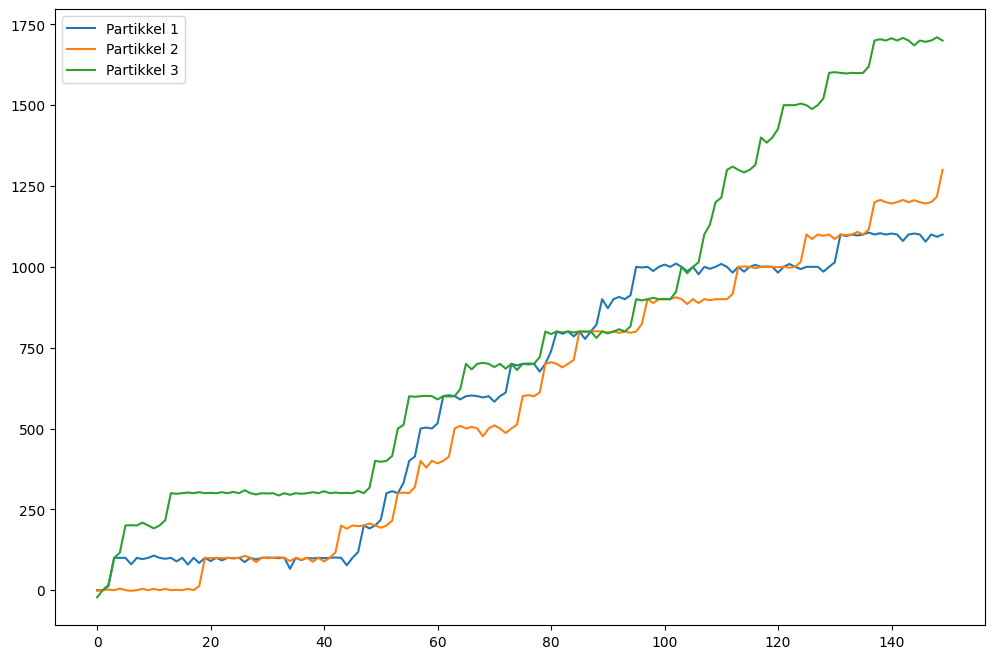

In [25]:
timeCycle = 2 * 75
number_of_particles = 3
alpha = 0.1
T_p = 200
N_x = 100
h = 1
delta_t = 1
beta = 1000

x_start =  np.zeros((timeCycle, number_of_particles)) # Array med alle partikklene i posisjon x=0, iterer gjennom partikler og tidssteg

x1, X1, J1 = sim2(T_p, N_x, x_start)
for i in range(number_of_particles):
    plt.plot(X1[:, i], label=f"Partikkel {i+1}")
plt.legend()
plt.show()

# b)

In [41]:
alpha = 0.8
T_p = 500
N_x = 20
number_of_particles = 12*N_x
timeCycle = 2 * 10
h = 20/100

integers = range(-N_x, N_x)
repeated_integers = np.array([i for i in integers for _ in range(6)])
x_start = np.zeros((timeCycle, number_of_particles))
x_start[0] = repeated_integers

x2, X2, J2 = sim2(T_p, N_x, x_start)

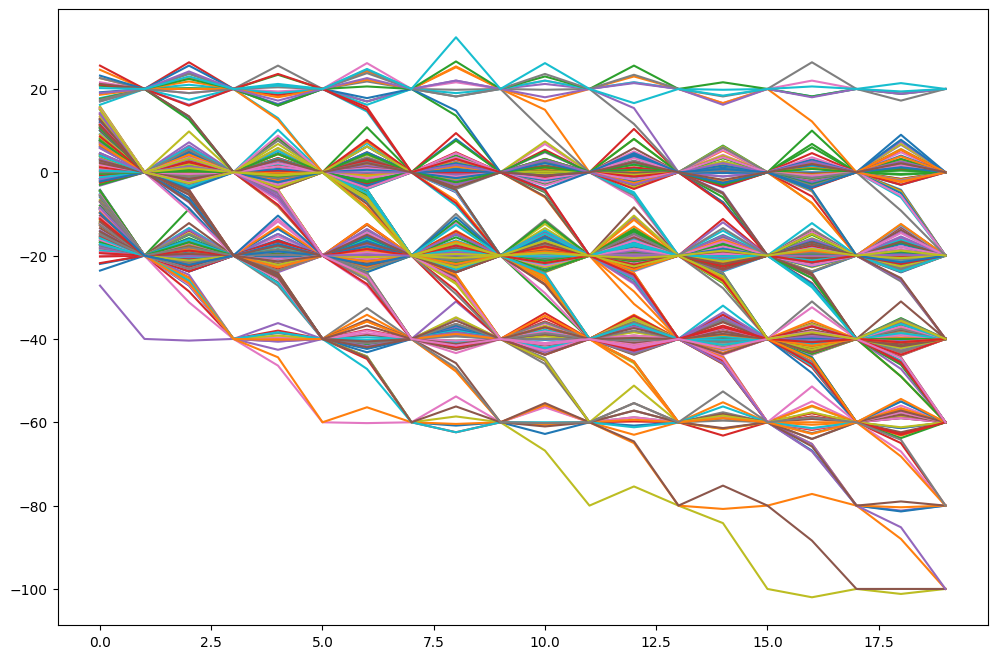

0.0
-0.0016666666666666607
0.002499999999999991
-0.0016666666666666607
-0.0008333333333333304
-0.0016666666666666607
-0.0016666666666666607
0.0
0.0008333333333333304
0.0008333333333333304
-0.0008333333333333304
0.0008333333333333304
0.0
0.002499999999999991
0.0
0.0008333333333333304
0.0008333333333333304
0.0008333333333333304
-0.0016666666666666607
0.0016666666666666607
-0.0016666666666666607
0.002499999999999991
-0.0008333333333333304
0.0
-0.0008333333333333304
0.0
-0.0008333333333333304
0.0016666666666666607
-0.0008333333333333304
-0.0016666666666666607
-0.0016666666666666607
-0.0008333333333333304
0.0
-0.0016666666666666607
0.0008333333333333304
0.0008333333333333304
0.0
0.0016666666666666607
0.0008333333333333304
0.0008333333333333304
0.0008333333333333304
-0.0008333333333333304
-0.0016666666666666607
0.002499999999999991
0.0
0.0016666666666666607
0.0
0.002499999999999991
-0.002499999999999991
0.0008333333333333304
0.0
-0.0016666666666666607
-0.0016666666666666607
0.000833333333333

' print(J_avg) '

In [55]:
for i in range(number_of_particles):
    plt.plot(X2[:, i], label=f"Partikkel {i+1}")
plt.show()


J_avg = np.zeros(10)
for i in range(10):
    J_avg[i] = np.mean(J2[i*2*T_p:(i+1)*2*T_p])

""" for i in range(len(J2)):
    print(J2[i])
print(J_avg) """